In [98]:
from line_follower_detailed import LineFollower

In [99]:
class Config:
    OVERLAY = False

In [100]:
config = Config()
with open("my-config.next.py", 'r') as file:
    exec(file.read(), globals(), config.__dict__)



In [101]:
config.__dict__

{'CAMERA_TYPE': 'PICAM',
 'IMAGE_W': 320,
 'IMAGE_H': 240,
 'DRIVE_TRAIN_TYPE': 'PWM_STEERING_THROTTLE',
 'PWM_STEERING_THROTTLE': {'PWM_STEERING_PIN': 'PCA9685.1:40.1',
  'PWM_STEERING_SCALE': 1.0,
  'PWM_STEERING_INVERTED': False,
  'PWM_THROTTLE_PIN': 'PCA9685.1:40.0',
  'PWM_THROTTLE_SCALE': 1.0,
  'PWM_THROTTLE_INVERTED': False,
  'STEERING_LEFT_PWM': 455,
  'STEERING_RIGHT_PWM': 264,
  'THROTTLE_FORWARD_PWM': 383,
  'THROTTLE_STOPPED_PWM': 350,
  'THROTTLE_REVERSE_PWM': 0},
 'CV_CONTROLLER_MODULE': 'line_follower_detailed',
 'CV_CONTROLLER_CLASS': 'LineFollower',
 'CV_CONTROLLER_INPUTS': ['cam/image_array'],
 'CV_CONTROLLER_OUTPUTS': ['pilot/steering',
  'pilot/throttle',
  'cv/image_array'],
 'CV_CONTROLLER_CONDITION': 'run_pilot',
 'SCAN_Y': 80,
 'SCAN_HEIGHT': 100,
 'COLOR_THRESHOLD_LOW': (20, 102, 131),
 'COLOR_THRESHOLD_HIGH': (47, 255, 255),
 'EDGE_COLOR_THRESHOLD_LOW': (0, 0, 203),
 'EDGE_COLOR_THRESHOLD_HIGH': (179, 30, 255),
 'TARGET_PIXEL': 160,
 'TARGET_THRESHOLD': 10,

In [102]:
## Override some of the config values


In [103]:
from simple_pid import PID

# Initialize PID controller
pid = PID(Kp=0.1, Ki=0.01, Kd=0.005, setpoint=0)

In [104]:
from matplotlib import pyplot as plt
import cv2

In [105]:
def show_rgb_image(bgr_image):
    # Convert the image from BGR to RGB
    cpy = bgr_image.copy()
    image_rgb = cv2.cvtColor(cpy, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.axis('off')  # Turn off axis
    plt.show()

In [106]:
def show_rgb_image(image_rgb):
    plt.imshow(image_rgb)
    plt.axis('off')  # Turn off axis
    plt.show()

In [107]:
image_path = '../../../../vision/donkeypi2_test_5.png'
bgr_image = cv2.imread(
    image_path
)  

if bgr_image is None:
    raise ValueError(f"Could not read image from path: {image_path}")
print(
    f"Image size: {bgr_image.shape[1]}x{bgr_image.shape[0]}, "
)
# Resize the frame to the specified dimensions
frame_resized = cv2.resize(bgr_image, (config.__dict__['IMAGE_W'], config.__dict__['IMAGE_H']))
print(f"Image resized: {frame_resized.shape[1]}x{frame_resized.shape[0]}, ")
# Convert the frame from BGR to RGB color space
image_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)

Image size: 1080x808, 
Image resized: 320x240, 


In [108]:
line_follower = LineFollower(pid, config)

In [109]:
steering, throttle, run_image = line_follower.run(image_rgb)
assert run_image is not None
assert run_image.shape == image_rgb.shape


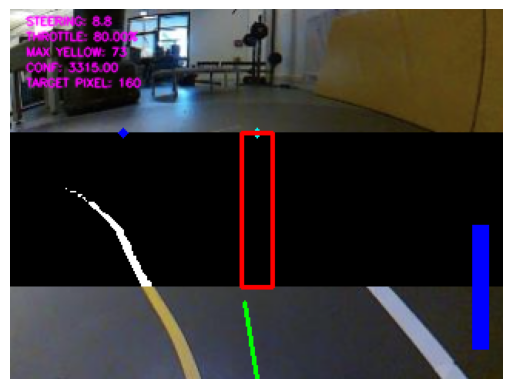

In [110]:
# Just try running the entire pipeline
show_rgb_image(run_image)

## Now lets break it down

In [111]:
max_yellow, confidence, mask = line_follower.get_i_color(image_rgb)
max_yellow, confidence  

(73, 3315)

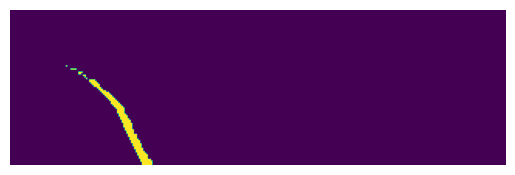

In [112]:
show_rgb_image(mask)

In [113]:
# Save the mask to a file for analysis  
cv2.imwrite('mask.png', cv2.cvtColor(mask, cv2.COLOR_RGB2BGR))

True

In [114]:
final_image = line_follower.overlay_display(
    image_rgb, 
    mask, 
    max_yellow, 
    confidence,
    config.__dict__['TARGET_PIXEL']
    )

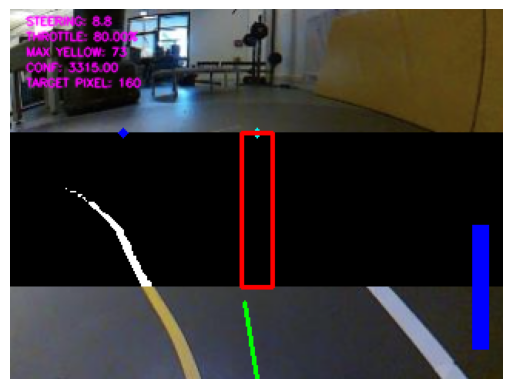

In [115]:
show_rgb_image(final_image)

# Lets try some hough stuff

In [116]:
line_detection_results = line_follower.run_line_detection_on_hsv_mask(mask)
line_detection_results

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

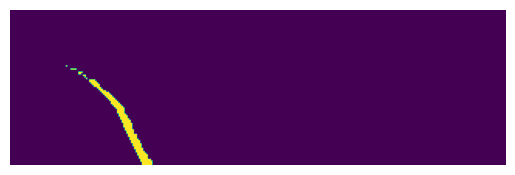

In [117]:
original_mask = line_detection_results[0]
show_rgb_image(original_mask)

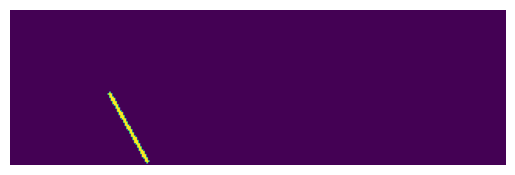

In [118]:
line_mask = line_detection_results[1]
show_rgb_image(line_mask)

## Try manually doing hough transform on the image

In [119]:
config.__dict__

{'CAMERA_TYPE': 'PICAM',
 'IMAGE_W': 320,
 'IMAGE_H': 240,
 'DRIVE_TRAIN_TYPE': 'PWM_STEERING_THROTTLE',
 'PWM_STEERING_THROTTLE': {'PWM_STEERING_PIN': 'PCA9685.1:40.1',
  'PWM_STEERING_SCALE': 1.0,
  'PWM_STEERING_INVERTED': False,
  'PWM_THROTTLE_PIN': 'PCA9685.1:40.0',
  'PWM_THROTTLE_SCALE': 1.0,
  'PWM_THROTTLE_INVERTED': False,
  'STEERING_LEFT_PWM': 455,
  'STEERING_RIGHT_PWM': 264,
  'THROTTLE_FORWARD_PWM': 383,
  'THROTTLE_STOPPED_PWM': 350,
  'THROTTLE_REVERSE_PWM': 0},
 'CV_CONTROLLER_MODULE': 'line_follower_detailed',
 'CV_CONTROLLER_CLASS': 'LineFollower',
 'CV_CONTROLLER_INPUTS': ['cam/image_array'],
 'CV_CONTROLLER_OUTPUTS': ['pilot/steering',
  'pilot/throttle',
  'cv/image_array'],
 'CV_CONTROLLER_CONDITION': 'run_pilot',
 'SCAN_Y': 80,
 'SCAN_HEIGHT': 100,
 'COLOR_THRESHOLD_LOW': (20, 102, 131),
 'COLOR_THRESHOLD_HIGH': (47, 255, 255),
 'EDGE_COLOR_THRESHOLD_LOW': (0, 0, 203),
 'EDGE_COLOR_THRESHOLD_HIGH': (179, 30, 255),
 'TARGET_PIXEL': 160,
 'TARGET_THRESHOLD': 10,

In [120]:
from dataclasses import dataclass

@dataclass
class HoughLineDetectionParams:
    rho: int
    theta: int
    threshold: int
    min_line_length: int
    max_line_gap: int

In [121]:
hough_params = HoughLineDetectionParams(
    rho=config.__dict__['HOUGH_RHO'],
    theta=config.__dict__['HOUGH_THETA'],
    threshold=config.__dict__['HOUGH_THRESHOLD'],
    min_line_length=config.__dict__['HOUGH_MIN_LINE_LENGTH'],
    max_line_gap=config.__dict__['HOUGH_MAX_LINE_GAP'],
)
lines = cv2.HoughLinesP(
    original_mask,
    rho=hough_params.rho,
    theta=hough_params.theta,
    threshold=hough_params.threshold,
    minLineLength=hough_params.min_line_length,
    maxLineGap=hough_params.max_line_gap,
)

In [122]:
type(lines)

numpy.ndarray

In [123]:
lines

array([[[64, 54, 88, 97]]], dtype=int32)

In [125]:
import numpy as np

In [136]:
copy_image = np.copy(cv2.cvtColor(original_mask, cv2.COLOR_GRAY2BGR))
line_color = (0, 255, 0)


for line in lines:
    for x1, y1, x2, y2 in line:
        cv2.line(copy_image, (x1, y1), (x2, y2), line_color, 2)

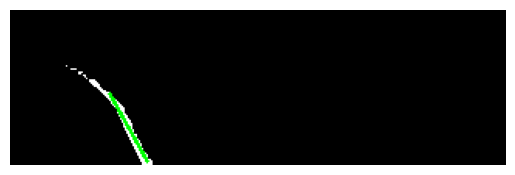

In [137]:
show_rgb_image(copy_image)